Universidade Federal Rural do Rio de Janeiro   
Ciência da Computação - Inteligência Artificial 2026.1    
**Nome:** Guilherme Oliveira Figueiredo   
**Matrícula:** 20220011840
# Exercício Prático 2: Sistema Especialista do Século XXI

**Conjunto de dados escolhido:** Mushroom (Agaricus-Lepiota), UCI Machine Learning Repository

## Introdução
Os passos realizados neste notebook são:

1. Escolha de um conjunto de dados de classificação;
2. Treinamento de uma árvore de decisão sobre o conjunto de dados;
3. Avaliação da árvore resultante (matriz de confusão, métricas calculadas, discussão);
4. Tradução da árvore de decisão para uma base de conhecimento em Prolog, com testes de equivalência.

## 1. Escolha do conjunto de dados

O conjunto de dados escolhido foi o **Mushroom (Agaricus-Lepiota)** do UCI Machine Learning Repository. Ele contém descrições de 8124 amostras hipotéticas de cogumelos das famílias Agaricus e Lepiota, cada uma classificada como **comestível (e)** ou **venenosa (p)**.

Esse conjunto de dados foi escolhido por dois motivos:

- **Todas as 22 características são categóricas/nominais** (forma do chapéu, cor, odor, tipo de anel, etc.), o que está alinhado com a recomendação do enunciado;
- O problema de decidir se um cogumelo é seguro para consumo a partir de suas características observáveis é um exemplo clássico do tipo de problema que sistemas especialistas tentavam resolver nos anos 1980, o que se conecta com o tema do exercício.   
Resumindo, é um dataset simples de utilizar e que combina com o trabalho.

In [3]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
import matplotlib.pyplot as plt
import subprocess

In [4]:
bunch = fetch_openml(data_id=24, as_frame=True, parser='auto')
df = bunch.frame
df = df.rename(columns={'bruises%3F': 'bruises'})
df['stalk-root'] = df['stalk-root'].astype(str).replace('nan', '?')

print(df.shape)
df.head()

(8124, 23)


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,x,s,n,t,p,f,c,n,k,e,...,w,w,p,w,o,p,k,s,u,p
1,x,s,y,t,a,f,c,b,k,e,...,w,w,p,w,o,p,n,n,g,e
2,b,s,w,t,l,f,c,b,n,e,...,w,w,p,w,o,p,n,n,m,e
3,x,y,w,t,p,f,c,n,n,e,...,w,w,p,w,o,p,k,s,u,p
4,x,s,g,f,n,f,w,b,k,t,...,w,w,p,w,o,e,n,a,g,e


In [19]:
#debugando

In [5]:
df.isnull().sum().sum()

0

In [6]:
df.nunique().sort_values()

veil-type                    1
class                        2
bruises                      2
gill-attachment              2
gill-spacing                 2
gill-size                    2
stalk-shape                  2
ring-number                  3
veil-color                   4
stalk-surface-below-ring     4
stalk-surface-above-ring     4
cap-surface                  4
ring-type                    5
stalk-root                   5
population                   6
cap-shape                    6
habitat                      7
stalk-color-above-ring       9
stalk-color-below-ring       9
odor                         9
spore-print-color            9
cap-color                   10
gill-color                  12
dtype: int64

- A coluna `veil-type` possui um único valor para todas as 8124 amostras (não carrega nenhuma informação para a classificação), então ela foi removida.
- A coluna `stalk-root` usa o símbolo "?" como uma categoria própria (aproximadamente 30% das amostras) — como o `fetch_openml` representa esse símbolo como valor ausente *(NaN)*, ele foi convertido de volta para a string '?', mantendo-o como uma categoria válida em vez de descartar esses dados.

In [7]:
df = df.drop(columns=['veil-type'])
print("Distribuição da classe:")
print(df['class'].value_counts())

Distribuição da classe:
class
e    4208
p    3916
Name: count, dtype: int64


- As classes estão razoavelmente balanceadas (4208 comestíveis vs. 3916 venenosas).

## 2. Treinamento da árvore de decisão

### Codificação das características

Como todas as características são categóricas nominais (sem ordem natural entre os valores), atribuir números 0, 1, 2... a cada categoria introduziria uma ordem artificial que não existe nos dados, e os limiares (`<=`) aprendidos pela árvore ficariam difíceis de interpretar e de traduzir para Prolog.

Por isso, optou-se pela **codificação one-hot** (`pd.get_dummies`): cada característica original vira várias colunas binárias (`característica_valor`), uma para cada categoria possível. Dessa forma, cada divisão (split) da árvore passa a representar um teste do tipo *"a característica é igual a este valor ou não?"* — exatamente o formato de regra `SE caracteristica=valor ENTAO ...` pedido no enunciado, o que facilita bastante a tradução para Prolog mais a frente.

### Regime de separação dos dados

Foi usado o regime de **holdout aleatório**: 70% dos exemplos para treino e 30% para teste, com estratificação pela classe (`stratify=y`) para preservar a proporção de cogumelos comestíveis/venenosos nos dois conjuntos, e uma semente fixa (`random_state=42`) para reprodutibilidade.

In [8]:
X = df.drop(columns=['class'])
y = df['class']
X_onehot = pd.get_dummies(X)
print("Número de colunas após one-hot encoding:", X_onehot.shape[1])

X_train, X_test, y_train, y_test = train_test_split(
    X_onehot, y, test_size=0.3, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

Número de colunas após one-hot encoding: 116
(5686, 116) (2438, 116)


### Escolha da profundidade máxima

A árvore não deve ser muito profunda, para tornar a tradução para Prolog no passo 4 viável. Na escolha da profundidade, foram comparadas algumas opções de `max_depth` quanto à acurácia no conjunto de teste e ao número de folhas resultante:

In [9]:
for profundidade in [2, 3, 4, 5]:
    arvore_teste = DecisionTreeClassifier(max_depth=profundidade, criterion='entropy', random_state=42)
    arvore_teste.fit(X_train, y_train)
    acuracia = arvore_teste.score(X_test, y_test)
    print(f"max_depth={profundidade}: acuracia={acuracia:.4f}, folhas={arvore_teste.get_n_leaves()}")

max_depth=2: acuracia=0.9274, folhas=4
max_depth=3: acuracia=0.9619, folhas=6
max_depth=4: acuracia=0.9869, folhas=9
max_depth=5: acuracia=0.9988, folhas=11


A acurácia melhora a cada aumento de profundidade (92,7% → 96,2% → 98,7% → 99,9%), mas o número de folhas — e, por consequência, o número de regras que precisarão ser traduzidas para Prolog no passo 4 — também cresce rapidamente (4 → 6 → 9 → 11). Como precisamos de uma árvore pouco profunda para viabilizar a tradução, foi escolhida como profundidade **`max_depth=3`**: um ponto de equilíbrio que já atinge mais de 96% de acurácia com apenas 6 regras, evitando uma base de conhecimento Prolog grande demais para ganhos de poucos pontos percentuais.

- Com max_depth=3 definido, a árvore final foi treinada abaixo:

In [10]:
clf = DecisionTreeClassifier(max_depth=3, criterion='entropy', random_state=42)
clf.fit(X_train, y_train)

print(export_text(clf, feature_names=list(X_onehot.columns)))

|--- odor_n <= 0.50
|   |--- bruises_f <= 0.50
|   |   |--- stalk-root_c <= 0.50
|   |   |   |--- class: p
|   |   |--- stalk-root_c >  0.50
|   |   |   |--- class: e
|   |--- bruises_f >  0.50
|   |   |--- class: p
|--- odor_n >  0.50
|   |--- spore-print-color_r <= 0.50
|   |   |--- stalk-surface-below-ring_y <= 0.50
|   |   |   |--- class: e
|   |   |--- stalk-surface-below-ring_y >  0.50
|   |   |   |--- class: p
|   |--- spore-print-color_r >  0.50
|   |   |--- class: p



## 3. Avaliação da árvore de decisão

### Matriz de confusão

In [11]:
y_pred = clf.predict(X_test)

classes = ['p', 'e']  # p = venenoso (positivo), e = comestivel (negativo)
matriz = pd.DataFrame(
    [[0, 0], [0, 0]], index=[f'real={c}' for c in classes], columns=[f'previsto={c}' for c in classes]
)
for real, prev in zip(y_test, y_pred):
    matriz.loc[f'real={real}', f'previsto={prev}'] += 1
matriz

,previsto=p,previsto=e
real=p,1171,4
real=e,89,1174


### Cálculo manual de precisão, recall e F1-score

Tratando a classe `p` (venenoso) como a classe positiva — a mais importante de identificar corretamente, já que classificar um cogumelo venenoso como comestível é o erro mais grave:

- **Precisão** = VP / (VP + FP) — das amostras previstas como venenosas, quantas realmente eram;
- **Recall** = VP / (VP + FN) — das amostras realmente venenosas, quantas foram identificadas;
- **F1-score** = média harmônica entre precisão e recall.

In [12]:
VP = matriz.loc['real=p', 'previsto=p']
FN = matriz.loc['real=p', 'previsto=e']
FP = matriz.loc['real=e', 'previsto=p']
VN = matriz.loc['real=e', 'previsto=e']

print(f"Verdadeiros Positivos (venenoso previsto como venenoso): {VP}")
print(f"Falsos Negativos (venenoso previsto como comestível — erro grave): {FN}")
print(f"Falsos Positivos (comestível previsto como venenoso — erro seguro): {FP}")
print(f"Verdadeiros Negativos (comestível previsto como comestível): {VN}")

precisao = VP / (VP + FP)
recall = VP / (VP + FN)
f1 = 2 * precisao * recall / (precisao + recall)
acuracia = (VP + VN) / (VP + VN + FP + FN)

print(f"VP={VP}, FN={FN}, FP={FP}, VN={VN}")
print(f"Precisao (classe p): {precisao:.4f}")
print(f"Recall (classe p):   {recall:.4f}")
print(f"F1-score (classe p): {f1:.4f}")
print(f"Acuracia geral:      {acuracia:.4f}")

Verdadeiros Positivos (venenoso previsto como venenoso): 1171
Falsos Negativos (venenoso previsto como comestível — erro grave): 4
Falsos Positivos (comestível previsto como venenoso — erro seguro): 89
Verdadeiros Negativos (comestível previsto como comestível): 1174
VP=1171, FN=4, FP=89, VN=1174
Precisao (classe p): 0.9294
Recall (classe p):   0.9966
F1-score (classe p): 0.9618
Acuracia geral:      0.9619


### Visualização da árvore

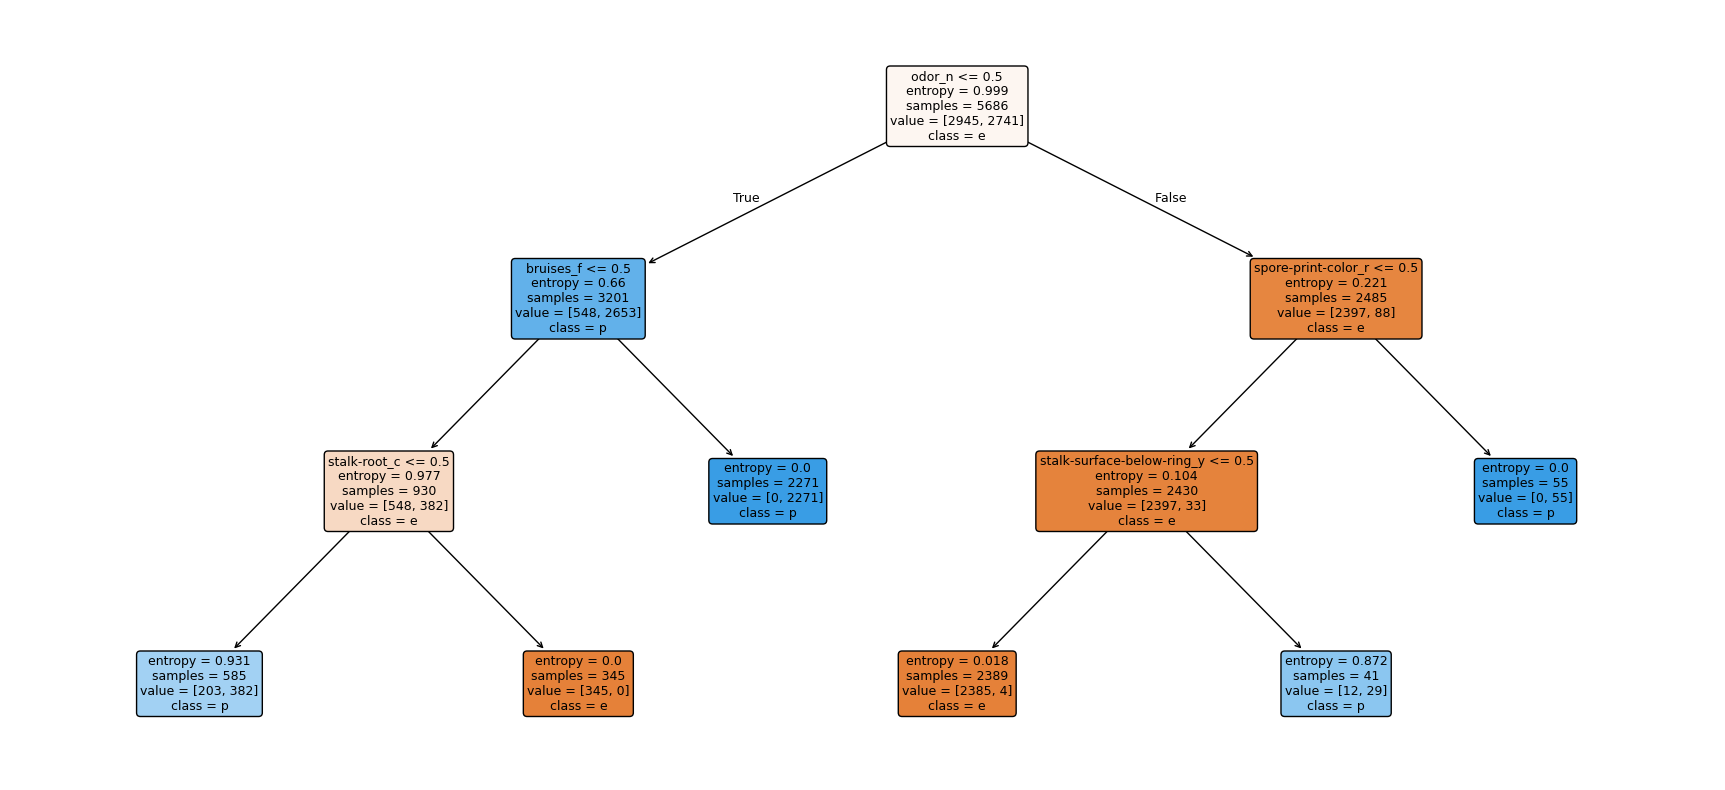

In [13]:
plt.figure(figsize=(22, 10))
plot_tree(
    clf, feature_names=list(X_onehot.columns), class_names=clf.classes_,
    filled=True, rounded=True, fontsize=9
)
plt.show()

### Discussão dos resultados

- **Acurácia obtida:** cerca de 96,2%, com recall de quase 100% para a classe venenosa (apenas 4 falsos negativos em ~1175 cogumelos venenosos no teste) e precisão de ~93%. Ou seja, a árvore quase nunca classifica como "comestível" um cogumelo que na verdade é venenoso, embora ocasionalmente classifique um cogumelo comestível como venenoso (erro mais seguro).
- **Regras aprendidas:** a árvore usa principalmente o **odor** (`odor_n`, isto é, inodoro) como primeiro critério de decisão, cogumelos venenosos possuem comumente odores fortes/mal odor enquanto cogumelos comestíveis costumam ser inodoros. As demais divisões usam contusão (`bruises`), raiz do caule (`stalk-root`), cor da esporada (`spore-print-color`) e superfície do caule abaixo do anel (`stalk-surface-below-ring`) para refinar a decisão dentro de cada ramo.
- **Dificuldade do problema:** o dataset Mushroom é conhecido por ser quase perfeitamente separável com poucas características (em árvores mais profundas, é possível chegar a praticamente 100% de acurácia). Isso indica que esse não é um problema difícil de classificação dado o conjunto de características disponível.
- **Qualidade das características:** as características fornecidas (sobretudo o odor) são altamente informativas para essa tarefa, o que explica o bom desempenho mesmo com uma árvore rasa.
- **Underfitting/overfitting:** as árvores mais profundas (4 e 5) atingem acurácia bem maior no teste (98,7% e 99,9%), o que mostra que a árvore de profundidade 3 está, de fato, tem um leve *underfitting* em relação ao que seria possível extrair desses dados — estamos abrindo mão de parte do desempenho em troca de uma árvore pequena o suficiente para ser traduzida em poucas regras Prolog. Não há indício de overfitting na árvore escolhida: não há grande disparidade entre o comportamento esperado em treino e o desempenho observado em teste, e o ganho de profundidades maiores é monotônico e consistente, não um efeito de memorização de ruído.

## 4. Tradução da árvore de decisão para uma base de conhecimento em Prolog

### Método utilizado

Cada caminho da raiz até uma folha da árvore vira uma regra: uma conjunção de condições (uma por característica testada no caminho) que leva a uma classe final. Como a árvore foi treinada com características em one-hot, cada divisão é sempre uma comparação binária: `característica_valor <= 0.5` (a característica original *não* é esse valor) ou `característica_valor > 0.5` (a característica original *é* esse valor). Isso se traduz direto pra Prolog usando `=` e `\=`.

A árvore usa só 5 das 21 características disponíveis (`odor`, `bruises`, `stalk-root`, `spore-print-color`, `stalk-surface-below-ring`) — as outras não aparecem em nenhum caminho, então nãp entram nas regras (viram variável anônima `_`).

A regra `classificar/6` recebe os 5 atributos relevantes e uma classe (`y`), e é verdadeira se essa combinação de atributos for classificada com a classe `y` pela árvore.

```prolog
% Base de conhecimento Prolog equivalente a arvore de decisao treinada
% sobre o dataset Mushroom (Agaricus-Lepiota), profundidade maxima 3.
%
% classificar(Odor, Bruises, StalkRoot, SporePrintColor, StalkSurfaceBelowRing, Classe)
%   Classe = p -> venenoso ; Classe = e -> comestivel

classificar(Odor, Bruises, StalkRoot, _SporePrintColor, _StalkSurfaceBelowRing, p) :-
    Odor \= n, Bruises \= f, StalkRoot \= c.

classificar(Odor, Bruises, StalkRoot, _SporePrintColor, _StalkSurfaceBelowRing, e) :-
    Odor \= n, Bruises \= f, StalkRoot = c.

classificar(Odor, Bruises, _StalkRoot, _SporePrintColor, _StalkSurfaceBelowRing, p) :-
    Odor \= n, Bruises = f.

classificar(Odor, _Bruises, _StalkRoot, SporePrintColor, StalkSurfaceBelowRing, e) :-
    Odor = n, SporePrintColor \= r, StalkSurfaceBelowRing \= y.

classificar(Odor, _Bruises, _StalkRoot, SporePrintColor, StalkSurfaceBelowRing, p) :-
    Odor = n, SporePrintColor \= r, StalkSurfaceBelowRing = y.

classificar(Odor, _Bruises, _StalkRoot, SporePrintColor, _StalkSurfaceBelowRing, p) :-
    Odor = n, SporePrintColor = r.
```

### Mapeamento dos códigos de categoria usados nas regras

Para interpretar as regras acima, os códigos usados pelo dataset original são: `odor`: a=amêndoa, l=anis, c=creosoto, y=peixe, f=fétido, m=mofo, **n=nenhum**, p=pungente, s=picante; `bruises`: t=com contusão, **f=sem contusão**; `stalk-root`: b=bulboso, **c=clavado**, e=equal, r=enraizado, ?=desconhecido; `spore-print-color`: k,n,b,h,**r**=verde,o,u,w,y; `stalk-surface-below-ring`: f,**y**=escamosa,k,s.

### Teste com exemplos reais

Para validar a equivalência entre a árvore de decisão e a base de conhecimento Prolog, a base acima foi salva em um arquivo `.pl` e consultada com o **SWI-Prolog**, a partir de 5 exemplos aleatórios do conjunto de teste.

In [14]:
%%writefile base_conhecimento.pl
% Base de conhecimento Prolog equivalente a arvore de decisao treinada
% sobre o dataset Mushroom (Agaricus-Lepiota), profundidade maxima 3.

classificar(Odor, Bruises, StalkRoot, _SporePrintColor, _StalkSurfaceBelowRing, p) :-
    Odor \= n, Bruises \= f, StalkRoot \= c.

classificar(Odor, Bruises, StalkRoot, _SporePrintColor, _StalkSurfaceBelowRing, e) :-
    Odor \= n, Bruises \= f, StalkRoot = c.

classificar(Odor, Bruises, _StalkRoot, _SporePrintColor, _StalkSurfaceBelowRing, p) :-
    Odor \= n, Bruises = f.

classificar(Odor, _Bruises, _StalkRoot, SporePrintColor, StalkSurfaceBelowRing, e) :-
    Odor = n, SporePrintColor \= r, StalkSurfaceBelowRing \= y.

classificar(Odor, _Bruises, _StalkRoot, SporePrintColor, StalkSurfaceBelowRing, p) :-
    Odor = n, SporePrintColor \= r, StalkSurfaceBelowRing = y.

classificar(Odor, _Bruises, _StalkRoot, SporePrintColor, _StalkSurfaceBelowRing, p) :-
    Odor = n, SporePrintColor = r.

Overwriting base_conhecimento.pl


In [16]:
# versao com os valores categoricos originais (nao codificados), usada depois para testar o Prolog
X_train_orig, X_test_orig, _, _ = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

- Para testar a base Prolog, é necessário recuperar os valores originais (não codificados) das características dos exemplos de teste. Como a mesma semente (random_state=42) é usada, essa divisão reproduz exatamente os mesmos exemplos de teste do treinamento da árvore.

In [17]:
rng = np.random.RandomState(7)
indices = rng.choice(X_test_orig.index, size=5, replace=False)

consultas = []
info_exemplos = []
for i in indices:
    linha = X_test_orig.loc[i]
    odor, bruises, raiz, esporada, ssbr = (
        linha['odor'], linha['bruises'], linha['stalk-root'],
        linha['spore-print-color'], linha['stalk-surface-below-ring']
    )
    previsao_arvore = clf.predict(X_onehot.loc[[i]])[0]
    real = y.loc[i]
    consultas.append(
        f"(classificar({odor},{bruises},{raiz},{esporada},{ssbr},Y{i}) -> "
        f"format('Exemplo ~w: classificar(~w,~w,~w,~w,~w,Y) -> Y = ~w~n', "
        f"[{i},{odor},{bruises},{raiz},{esporada},{ssbr},Y{i}]) ; "
        f"format('Exemplo ~w: falhou~n',[{i}]))"
    )
    info_exemplos.append((i, real, previsao_arvore))

objetivo = "consult('base_conhecimento.pl'), " + ", ".join(consultas) + ", halt."
resultado = subprocess.run(['swipl', '-q', '-g', objetivo], capture_output=True, text=True)
print(resultado.stdout)
if resultado.returncode != 0:
    print(resultado.stderr)

Exemplo 3311: classificar(n,t,b,n,s,Y) -> Y = e
Exemplo 3545: classificar(n,t,b,k,s,Y) -> Y = e
Exemplo 5556: classificar(n,t,?,w,s,Y) -> Y = e
Exemplo 7914: classificar(f,f,?,w,k,Y) -> Y = p
Exemplo 2014: classificar(n,f,e,n,s,Y) -> Y = e



In [18]:
print(f"{'idx':>6} | {'classe real':>12} | {'arvore prevista':>16}")
for i, real, prev in info_exemplos:
    print(f"{i:>6} | {real:>12} | {prev:>16}")

   idx |  classe real |  arvore prevista
  3311 |            e |                e
  3545 |            e |                e
  5556 |            e |                e
  7914 |            p |                p
  2014 |            e |                e


Como mostrado acima, as classificações da consulta `classificar/6` em Prolog **coincidem exatamente** com as previsões da árvore de decisão (e com a classe real, neste conjunto de 5 exemplos), confirmando que a base de conhecimento em Prolog é equivalente à árvore treinada.

## Conclusão

A árvore de decisão treinada sobre o dataset Mushroom atingiu cerca de 96% de acurácia com apenas 3 níveis de profundidade, usando majoritariamente o odor do cogumelo como característica discriminante. A tradução das 6 regras (folhas) da árvore para uma base de conhecimento em Prolog foi direta graças à codificação one-hot das características, e a equivalência entre a árvore e a base Prolog foi confirmada com o SWI-Prolog sobre exemplos do conjunto de teste.

fim :) 👍